In [1]:
#Choosing filtering parameter

In [49]:
import pandas as pd

ExampleData='1.xlsx'
df1=pd.DataFrame()
df1=pd.read_excel('../data/'+ExampleData)
df1=df1.dropna()

#df_ant - projection to z axis for anterior view
df_ant = df1[['l_hip_x','l_hip_y','l_knee_x','l_knee_y','l_ankle_x','l_ankle_y',
             'r_hip_x','r_hip_y','r_knee_x','r_knee_y','r_ankle_x','r_ankle_y']]

pd.set_option('mode.chained_assignment', None)
df_ant['l_tibia_x'] = df_ant['l_knee_x'] - df_ant['l_ankle_x']
df_ant['l_tibia_y'] = df_ant['l_knee_y'] - df_ant['l_ankle_y']
df_ant['l_femur_x'] = df_ant['l_hip_x'] - df_ant['l_knee_x']
df_ant['l_femur_y'] = df_ant['l_hip_y'] - df_ant['l_knee_y']
df_ant['r_tibia_x'] = df_ant['r_knee_x'] - df_ant['r_ankle_x']
df_ant['r_tibia_y'] = df_ant['r_knee_y'] - df_ant['r_ankle_y']
df_ant['r_femur_x'] = df_ant['r_hip_x'] - df_ant['r_knee_x']
df_ant['r_femur_y'] = df_ant['r_hip_y'] - df_ant['r_knee_y']

#lateral view
df_lat = df1[['torso_y', 'torso_z', 'waist_y','waist_z','l_hip_y','l_hip_z','l_knee_y','l_knee_z','l_ankle_y','l_ankle_z']]

df_lat['tor_wai_y'] = df_lat['torso_y'] - df_lat['waist_y']
df_lat['tor_wai_z'] = df_lat['torso_z'] - df_lat['waist_z']
df_lat['l_hip_wai_y'] = df_lat['waist_y'] - df_lat['l_hip_y']
df_lat['l_hip_wai_z'] = df_lat['waist_z'] - df_lat['l_hip_z']
df_lat['l_tibia_y'] = df_lat['l_knee_y'] - df_lat['l_ankle_y']
df_lat['l_tibia_z'] = df_lat['l_knee_z'] - df_lat['l_ankle_z']

import numpy as np
from scipy.signal import argrelextrema
import scipy

WindowSize=20
df1_filtered = df1.rolling(window=WindowSize).mean()
pd.set_option('mode.chained_assignment', None)
df1_filtered['l_tibia_x'] = df1_filtered['l_knee_x'] - df1_filtered['l_ankle_x']
df1_filtered['l_tibia_y'] = df1_filtered['l_knee_y'] - df1_filtered['l_ankle_y']
df1_filtered['l_femur_x'] = df1_filtered['l_hip_x'] - df1_filtered['l_knee_x']
df1_filtered['l_femur_y'] = df1_filtered['l_hip_y'] - df1_filtered['l_knee_y']
df1_filtered['r_tibia_x'] = df1_filtered['r_knee_x'] - df1_filtered['r_ankle_x']
df1_filtered['r_tibia_y'] = df1_filtered['r_knee_y'] - df1_filtered['r_ankle_y']
df1_filtered['r_femur_x'] = df1_filtered['r_hip_x'] - df1_filtered['r_knee_x']
df1_filtered['r_femur_y'] = df1_filtered['r_hip_y'] - df1_filtered['r_knee_y']

#lateral view
df1_filtered['tor_wai_y'] = df1_filtered['torso_y'] - df1_filtered['waist_y']
df1_filtered['tor_wai_z'] = df1_filtered['torso_z'] - df1_filtered['waist_z']
df1_filtered['l_hip_wai_y'] = df1_filtered['waist_y'] - df1_filtered['l_hip_y']
df1_filtered['l_hip_wai_z'] = df1_filtered['waist_z'] - df1_filtered['l_hip_z']
df1_filtered['l_tibia_y'] = df1_filtered['l_knee_y'] - df1_filtered['l_ankle_y']
df1_filtered['l_tibia_z'] = df1_filtered['l_knee_z'] - df1_filtered['l_ankle_z']

x = df1['torso_y'].rolling(window=WindowSize).mean().values
minima_indices = argrelextrema(x, np.less,order = 12)
m = minima_indices[0]
m

array([ 58, 165, 255, 340, 424])

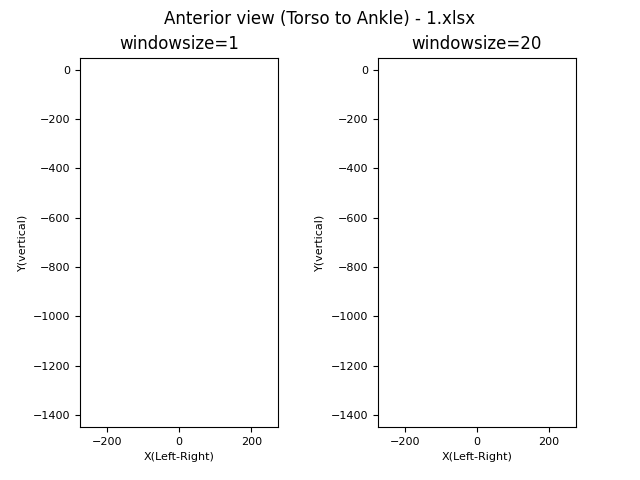

In [50]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

WS=[1, 10,20, 30]   #window sizes
NUM_WS=4

dff = []
for i in range(len(WS)):
    dff.append( df1.rolling(window=WS[i]).mean() )

# 1. Set up the Figure
fig, ax = plt.subplots(1,len(WS))
plt.subplots_adjust(wspace=0.5)
#fig.supylabel('Y(vertical)')
fig.suptitle('Anterior view (Torso to Ankle) - '+ExampleData)

left_legs = []
right_legs = []
frame_texts = []
for i in range(len(WS)):
    
    # Set subplot parameters
    ax[i].set_xlim(-275, 275)
    ax[i].set_ylim(-1450, 50)
    ax[i].set_xlabel('X(Left-Right)', fontsize=8)
    ax[i].set_ylabel('Y(vertical)', fontsize=8)
    ax[i].tick_params(axis='both',  labelsize=8)
    ax[i].set_title(f'windowsize={WS[i]}')
    

    left_leg, = ax[i].plot([], [], lw=2, color='red', marker='o',label='left leg')
    right_leg, = ax[i].plot([], [], lw=2, color='red',marker='o', label='right leg')
    left_legs.append(left_leg)
    right_legs.append(right_leg)

    frame_text = ax[i].text(0.02, 0.95, '', transform=ax[i].transAxes, fontsize=8)
    frame_texts.append( frame_text )
    
# 3. Initialize the Plot (optional but good practice)
def init():
    for i in range(len(WS)):
        left_legs[i].set_data([], [])
        right_legs[i].set_data([],[])
        frame_texts[i].set_text('')

    return left_legs, right_legs, frame_texts, # Return the artist(s) to be animated

# 4. Create the Update Function
def animate(i):

    # Update data for each frame
    for j in range(len(WS)):
        left_legs[j].set_data( dff[j][['l_ankle_x','l_knee_x','l_hip_x','waist_x','torso_x']].loc[i].values,
                       dff[j][['l_ankle_y','l_knee_y','l_hip_y','waist_y','torso_y']].loc[i].values)
        right_legs[j].set_data(dff[j][['r_ankle_x','r_knee_x','r_hip_x','waist_x']].loc[i].values, 
                  dff[j][['r_ankle_y','r_knee_y','r_hip_y','waist_y']].loc[i].values)
    
        frame_texts[j].set_text(f'Frame: {i:03d}') # Formats the number to have leading zeros
    return left_legs, right_legs, frame_texts # Return the artist(s) that were modified

# 5. Create the FuncAnimation Object
# interval is the delay between frames in milliseconds (e.g., 20ms = 50 fps)
# blit=True optimizes drawing by only updating changed parts
ani = FuncAnimation(fig, animate, frames=dff[0].shape[0], init_func=init,
                    interval=1, blit=True, repeat=False)

# 6. Show the Animation
plt.show()

# To save the animation as a GIF or MP4, you can use the save method:
ani.save('ani_save.gif', writer='pillow', fps=28) 

In [22]:
a = [1,2,3]

In [27]:
WS=[1, 10, 20, 30]   #window sizes
dff = []
for i in range(len(WS)):
    dff.append( df1.rolling(window=WS[i]).mean() )


In [33]:
dff[0][1:10]['torso_y']

1    -77.80215
2    -77.80215
3    -77.80215
4    -87.53446
5    -87.53446
6    -87.53446
7   -101.52920
8   -101.52920
9   -101.52920
Name: torso_y, dtype: float64

In [35]:
dff[0].shape[0]

447

In [42]:
df_ant.max()


l_hip_x       93.305961
l_hip_y     -261.836424
l_knee_x     193.869289
l_knee_y    -663.799651
l_ankle_x    271.133737
l_ankle_y   -985.265408
r_hip_x     -116.757209
r_hip_y     -264.623355
r_knee_x    -169.399154
r_knee_y    -665.993023
r_ankle_x   -203.396261
r_ankle_y   -987.648424
l_tibia_x    -48.121557
l_tibia_y    430.516005
l_femur_x    -41.944896
l_femur_y    467.620314
r_tibia_x     57.796322
r_tibia_y    421.206471
r_femur_x    105.512762
r_femur_y    462.635087
dtype: float64